# Taller: Representaciones de Texto - Word Embeddings y Embedding Contextual
## Curso de Inteligencia Artificial
---

En este taller explorarás de forma práctica cómo los embeddings transforman palabras en vectores numéricos que capturan relaciones semánticas y sintácticas.

**OBJETIVO**: 

- Completa cada sección escribiendo el código Python necesario para lograr los objetivos especificados.
- Usa las instrucciones y pistas en cada celda para guiarte en la solución.


## 1. Instalación de Dependencias

Primero, instalaremos las librerías necesarias:

In [5]:
# TODO: Instalar las siguientes librerías
# - gensim
# - nltk  
# - scikit-learn
# - matplotlib
# - numpy
# 
# INSTRUCCIONES:
# 1. Importa subprocess y sys
# 2. Crea una lista llamada 'librerías' con las librerías mencionadas
# 3. Usa un loop para instalar cada una con pip install
# 4. Imprime un mensaje de confirmación al final

import subprocess
import sys

# Escribe tu código aquí

librerias = ["gensim", "nltk", "scikit-learn", "matplotlib", "numpy"]

for libreria in librerias:
    subprocess.check_call([sys.executable, "-m", "pip", "install", libreria])

print("Todas las librerías fueron instaladas correctamente.")

Todas las librerías fueron instaladas correctamente.


## 2. Conceptos Fundamentales

In [6]:
# TODO: Comparar One-Hot Encoding vs Dense Embeddings
# 
# INSTRUCCIONES:
# 1. Define un vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
# 2. Crea un vector One-Hot para la primera palabra (todos ceros excepto el índice 0)
# 3. Crea un embedding denso usando números aleatorios (np.random.randn)
# 4. Imprime ambos vectores con sus características
#
# PISTAS:
# - Usa np.zeros() para crear el vector one-hot
# - Usa np.random.seed(42) para reproducibilidad
# - Usa np.random.randn() para crear embeddings densos

import numpy as np

# Escribe tu código aquí

vocabulario = ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']

# Vector One-Hot para la primera palabra
one_hot = np.zeros(len(vocabulario))
one_hot[0] = 1

# Embedding denso
np.random.seed(42)
embedding = np.random.randn(len(vocabulario))

# Imprimir resultados
print("=" * 60)
print("CONCEPTOS FUNDAMENTALES: ONE-HOT vs EMBEDDINGS")
print("=" * 60)

print(f"\nVocabulario: {vocabulario}")
print(f"Tamaño: {len(vocabulario)}")

print(f"\nOne-Hot: {one_hot}")
print("Propiedades: Muy disperso, no captura semántica")

print(f"\nEmbedding: {embedding}")
print("Propiedades: Denso, captura semántica implícita")

CONCEPTOS FUNDAMENTALES: ONE-HOT vs EMBEDDINGS

Vocabulario: ['inteligencia', 'artificial', 'máquina', 'aprendizaje', 'datos']
Tamaño: 5

One-Hot: [1. 0. 0. 0. 0.]
Propiedades: Muy disperso, no captura semántica

Embedding: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Propiedades: Denso, captura semántica implícita


## 3. Word2Vec - Entrenamiento Práctico

In [7]:
# TODO: Entrenar un modelo Word2Vec
#
# INSTRUCCIONES:
# 1. Importa Word2Vec de gensim
# 2. Importa funciones de nltk para tokenizar
# 3. Define un corpus de ejemplo sobre IA/ML (al menos 5 oraciones)
# 4. Tokeniza el corpus en oraciones y palabras
# 5. Entrena Word2Vec con los parámetros:
#    - vector_size=50
#    - window=5
#    - min_count=1
#    - sg=1 (Skip-gram)
# 6. Imprime información del modelo entrenado
#
# PISTAS:
# - Usa sent_tokenize para separar oraciones
# - Usa word_tokenize para separar palabras
# - Descarga los recursos necesarios de nltk con nltk.download()

from gensim.models import Word2Vec
from nltk.tokenize import sent_tokenize, word_tokenize
import nltk

# Descarga los recursos necesarios
# nltk.download('punkt')
nltk.download('punkt_tab')

# Corpus sobre inteligencia artificial (puedes modificarlo)
corpus = '''
El aprendizaje automático es una rama de la inteligencia artificial.
Las redes neuronales son modelos inspirados en el cerebro humano.
El aprendizaje profundo usa múltiples capas para aprender representaciones.
Los embeddings son vectores que capturan significado semántico de las palabras.
Word2Vec es un modelo que aprende embeddings de manera automática.
La inteligencia artificial ha revolucionado el procesamiento del lenguaje natural.
El aprendizaje supervisado usa datos etiquetados para entrenar modelos.
'''

# Escribe tu código aquí

# Tokenizar el corpus en oraciones y palabras
oraciones = sent_tokenize(corpus)
tokens = [word_tokenize(oracion.lower()) for oracion in oraciones]

# Entrenar el modelo Word2Vec
print("Entrenando Word2Vec...")
modelo = Word2Vec(tokens, vector_size=50, window=5, min_count=1, sg=1)

print("✓ Modelo entrenado")
print(f"  Vocabulario: {len(modelo.wv)} palabras")
print(f"  Dimensión: {modelo.vector_size}")

# Palabras similares a "inteligencia"
print("\nPalabras similares a \"inteligencia\":")
similares = modelo.wv.most_similar("inteligencia", topn=5)
for palabra, score in similares:
    print(f"  - {palabra:<20} ({score:.4f})")

Entrenando Word2Vec...


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


✓ Modelo entrenado
  Vocabulario: 51 palabras
  Dimensión: 50

Palabras similares a "inteligencia":
  - significado          (0.1906)
  - aprendizaje          (0.1903)
  - es                   (0.1900)
  - semántico            (0.1857)
  - aprender             (0.1760)


## 4. Visualización con t-SNE

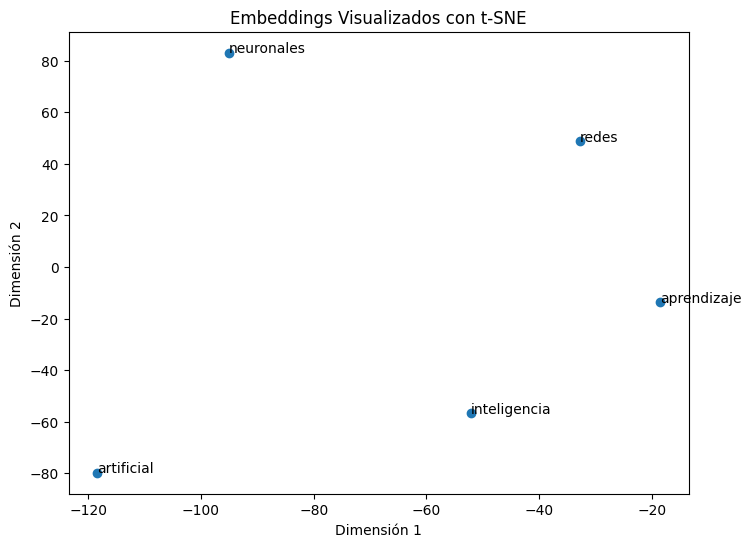

✓ Visualización completada


In [8]:
# TODO: Visualizar embeddings con t-SNE
#
# INSTRUCCIONES:
# 1. Selecciona 5 palabras que existan en el modelo entrenado
# 2. Obtén sus vectores del modelo
# 3. Usa t-SNE para reducir a 2 dimensiones (perplexity=2)
# 4. Crea un gráfico scatter con los puntos
# 5. Añade anotaciones con los nombres de las palabras
# 6. Añade título y etiquetas a los ejes
#
# PISTAS:
# - TSNE viene de sklearn.manifold
# - Usa plt.scatter() para graficar los puntos
# - Usa plt.annotate() para añadir etiquetas
# - Usa fit_transform() para ajustar y transformar los datos

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Selecciona palabras que existan en tu modelo
palabras = ['inteligencia', 'artificial', 'redes', 'neuronales', 'aprendizaje']

# Escribe tu código aquí

# Obtener los vectores de cada palabra
vectores = [modelo.wv[palabra] for palabra in palabras]
vectores = np.array(vectores)

# Reducir a 2 dimensiones con t-SNE
tsne = TSNE(n_components=2, perplexity=2, random_state=42)
vectores_2d = tsne.fit_transform(vectores)

# Crear el gráfico
plt.figure(figsize=(8, 6))
plt.scatter(vectores_2d[:, 0], vectores_2d[:, 1])

# Añadir etiquetas a cada punto
for i, palabra in enumerate(palabras):
    plt.annotate(palabra, (vectores_2d[i, 0], vectores_2d[i, 1]))

# Título y etiquetas de los ejes
plt.title("Embeddings Visualizados con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")

plt.show()
print("✓ Visualización completada")

## 5. Clasificación de Textos con Embeddings

In [9]:
# TODO: Clasificar textos usando embeddings
#
# INSTRUCCIONES:
# 1. Define una función que calcule el embedding promedio de un texto
#    - Tokeniza el texto
#    - Obtén vectores de palabras que existan en el modelo
#    - Retorna el promedio de esos vectores
# 2. Crea un dataset con 4 textos de ejemplo y sus etiquetas (positivo=1, negativo=0)
# 3. Obtén los embeddings promedios para cada texto
# 4. Entrena un clasificador LogisticRegression
# 5. Evalúa la precisión en los datos de entrenamiento
# 6. Haz una predicción en un nuevo texto de prueba
#
# PISTAS:
# - np.mean() para promediar vectores
# - LogisticRegression de sklearn.linear_model
# - clf.fit() para entrenar
# - clf.score() para evaluar
# - clf.predict() para predecir

from sklearn.linear_model import LogisticRegression
import numpy as np

def get_embedding_avg(texto, modelo):
    # Escribe la función aquí
    tokens = word_tokenize(texto.lower())
    vectores = [modelo.wv[palabra] for palabra in tokens if palabra in modelo.wv]
    if len(vectores) == 0:
        return np.zeros(modelo.vector_size)
    return np.mean(vectores, axis=0)

# Dataset de ejemplo (puedes crear tus propios ejemplos)
textos = [
    "El aprendizaje automático es increíble",
    "Las redes neuronales son muy poderosas",
    "No me gusta este modelo para nada",
    "Los resultados son muy malos"
]
etiquetas = [1, 1, 0, 0]  # 1=positivo, 0=negativo

# Escribe tu código aquí

# Obtener embeddings promedio para cada texto
X = [get_embedding_avg(texto, modelo) for texto in textos]
y = etiquetas

# Entrenar el clasificador
clf = LogisticRegression()
clf.fit(X, y)

# Evaluar precisión
precision = clf.score(X, y)
print(f"✓ Clasificador entrenado")
print(f"Precisión: {precision * 100:.2f}%")

# Predicción en un nuevo texto
nuevo_texto = "Una película asombrosa"
embedding_nuevo = get_embedding_avg(nuevo_texto, modelo)
prediccion = clf.predict([embedding_nuevo])[0]
etiqueta = "Positiva" if prediccion == 1 else "Negativa"

print(f'\nTexto: "{nuevo_texto}"')
print(f"Predicción: {etiqueta}")

✓ Clasificador entrenado
Precisión: 100.00%

Texto: "Una película asombrosa"
Predicción: Positiva


## 6. Conclusiones

En este taller hemos aprendido:
- Conceptos fundamentales de embeddings
- Entrenamiento de Word2Vec
- Visualización y análisis
- Aplicación en clasificación de textos

¡Felicidades por completar el taller!